# Entrenamiento Faster R-CNN

Tercer intento AAAA (a la tercera la vencida? O hacemos la de Keiko)

**v3:** Fusionar clases, y eliminar algunas otras

In [1]:
!pip install roboflow albumentations torchmetrics tqdm


Defaulting to user installation because normal site-packages is not writeable


## 1. Imports

In [2]:
import sys
!{sys.executable} -m pip install opencv-python torch torchvision numpy albumentations matplotlib tqdm Pillow roboflow torchmetrics

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import time
import json
import random
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import torch
import torch.nn.functional as F
import numpy as np
import torchvision
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as patchesS

from tqdm import tqdm
from PIL import Image
from roboflow import Roboflow
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
import torchvision.models.detection.roi_heads as _roi_heads_module


C:\Users\ricar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
print(f"Versión de PyTorch: {torch.__version__}")
print(f"¿CUDA disponible?: {torch.cuda.is_available()}")
print(f"Dispositivo actual: {torch.cuda.current_device() if torch.cuda.is_available() else 'CPU'}")

Versión de PyTorch: 2.12.1+cu130
¿CUDA disponible?: True
Dispositivo actual: 0


## 2. Configuración

In [ ]:
CONFIG = {
    # Dataset Roboflow
    "roboflow_api_key": "Az5***Aj",
    "roboflow_workspace": "joses-workspace-nqi4z",
    "roboflow_project": "Carritos-Detector",
    "roboflow_version": 1,
    "dataset_dir": "./Carritos-Detector-1",

    # Split
    "train_ratio": 0.80,
    "val_ratio":   0.10,
    "test_ratio":  0.10,

    # Modelo
    "num_classes": 3 + 1,      # 3 clases (Carro, Mototaxi, Persona) + background
    "unfreeze_layers": ("layer3", "layer4"),   # capas del backbone que SI se entrenan (fine-tuning)

    # Entrenamiento
    "epochs": 100,
    "batch_size": 2,
    "lr_head": 1e-3,           # LR para RPN + ROI heads (capas nuevas / re-inicializadas)
    "lr_backbone": 1e-4,       # LR mas bajo para layer3/layer4 descongeladas (fine-tuning suave)
    "weight_decay": 5e-4,
    "num_workers": 0,
    "seed": 42,

    # Scheduler
    "scheduler": "cosine",     # antes: StepLR con decaimiento agresivo (apagaba el LR desde la epoca 20)
    "lr_min": 1e-6,

    # Manejo de desbalance de clases
    "use_class_weights": True,
    "use_focal_loss": True,
    "focal_gamma": 2.0,
    "class_weight_max": 8.0,   # clip para no sobre-corregir clases minoritarias

    # Evaluacion
    "iou_thresholds": [0.50, 0.75],
    "score_threshold": 0.5,

    # Checkpoints
    "checkpoint_dir": "./checkpoints",
    "save_every": 5,
}


In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Usando dispositivo: {DEVICE}")


[INFO] Usando dispositivo: cuda


In [7]:
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])


## 3. Dataset
El dataset fue hecho manualmente desde Roboflow. El grupo estuvo clasificando todas las imagenes y asignando cada objeto una clase respectiva.

Para poder usarlo, usamos la vía de cargarla desde la nube que ofrece el mismo Roboflow.

In [8]:
rf = Roboflow(api_key=CONFIG["roboflow_api_key"])
workspace = rf.workspace("joses-workspace-nqi4z")
print(workspace.projects())


loading Roboflow workspace...
['joses-workspace-nqi4z/carritos-detector']


In [9]:
project = rf.workspace("joses-workspace-nqi4z").project("carritos-detector")
print(project.versions())


loading Roboflow workspace...
loading Roboflow project...


In [10]:
dataset_dir = Path(CONFIG["dataset_dir"])
if dataset_dir.exists():
    print(f"[INFO] Dataset ya encontrado en: {dataset_dir}")
else:
    print("[INFO] Descargando dataset desde Roboflow...")
    rf = Roboflow(api_key=CONFIG["roboflow_api_key"])
    project = rf.workspace("joses-workspace-nqi4z").project("carritos-detector")
    dataset = project.version(1).download("coco")


[INFO] Dataset ya encontrado en: Carritos-Detector-1


## 4. Parseo de anotaciones COCO y splits

In [11]:
def load_coco_annotations(json_path: str):
    with open(json_path, "r") as f:
        coco = json.load(f)
    categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
    ann_by_image = defaultdict(list)
    for ann in coco["annotations"]:
        ann_by_image[ann["image_id"]].append(ann)
    images = [img for img in coco["images"] if ann_by_image[img["id"]]]
    return images, ann_by_image, categories


In [12]:
import os
print("Directorio de trabajo actual:", os.getcwd())
print("¿Existe la carpeta?:", os.path.exists("Carritos-Detector-1"))

Directorio de trabajo actual: c:\Users\ricar\OneDrive\Documentos\Procesamiento de Imagenes\TF Procesamiento de Imagenes
¿Existe la carpeta?: True


In [13]:
# Detectar splits de Roboflow (train/valid/test)
roboflow_splits = {
    "train": dataset_dir / "train",
    "val":   dataset_dir / "valid",
    "test":  dataset_dir / "test",
}
has_roboflow_splits = all(
    (p / "_annotations.coco.json").exists() for p in roboflow_splits.values()
)

if has_roboflow_splits:
    print("[INFO] Splits de Roboflow detectados (train/valid/test).")
    splits = {}
    categories = None
    for split_name, split_dir in roboflow_splits.items():
        images, ann_by_image, cats = load_coco_annotations(
            str(split_dir / "_annotations.coco.json")
        )
        splits[split_name] = {
            "images": images,
            "ann_by_image": ann_by_image,
            "img_dir": split_dir,
        }
        if categories is None:
            categories = cats
else:
    all_jsons = list(dataset_dir.rglob("_annotations.coco.json"))
    if not all_jsons:
        raise FileNotFoundError(f"No se encontró ningún _annotations.coco.json en {dataset_dir}")
    json_path = all_jsons[0]
    img_dir = json_path.parent
    print(f"[INFO] Split manual 80/10/10 desde: {json_path}")
    images, ann_by_image, categories = load_coco_annotations(str(json_path))
    random.shuffle(images)
    n = len(images)
    n_train = int(n * CONFIG["train_ratio"])
    n_val = int(n * CONFIG["val_ratio"])
    splits = {
        "train": {"images": images[:n_train], "ann_by_image": ann_by_image, "img_dir": img_dir},
        "val":   {"images": images[n_train:n_train+n_val], "ann_by_image": ann_by_image, "img_dir": img_dir},
        "test":  {"images": images[n_train+n_val:], "ann_by_image": ann_by_image, "img_dir": img_dir},
    }

print(f"[INFO] Clases: {categories}")
print(f"[INFO] Imágenes → train: {len(splits['train']['images'])} | "
      f"val: {len(splits['val']['images'])} | test: {len(splits['test']['images'])}")


[INFO] Splits de Roboflow detectados (train/valid/test).
[INFO] Clases: {0: 'Carritos-Detector', 1: 'Ambulante', 2: 'Bus', 3: 'Camion', 4: 'Carro', 5: 'Combi', 6: 'Motocarga', 7: 'Motocicleta', 8: 'Mototaxi', 9: 'Persona'}
[INFO] Imágenes → train: 807 | val: 101 | test: 101


In [14]:
# ==============================================================================
# v3: Remapeo de clases
# - ELIMINAR: Ambulante (1), Motocarga (6), Motocicleta (7)
# - FUSIONAR dentro de Carro: Bus (2), Camion (3), Combi (5)
# - Nuevos IDs: Carro=1, Mototaxi=2, Persona=3
# ==============================================================================

OLD_TO_NEW = {
    1: None,       # Ambulante  -> ELIMINAR
    2: 1,          # Bus        -> Carro
    3: 1,          # Camion     -> Carro
    4: 1,          # Carro      -> Carro
    5: 1,          # Combi      -> Carro
    6: None,       # Motocarga  -> ELIMINAR
    7: None,       # Motocicleta-> ELIMINAR
    8: 2,          # Mototaxi   -> Mototaxi
    9: 3,          # Persona    -> Persona
}

NEW_CATEGORIES = {
    1: "Carro",
    2: "Mototaxi",
    3: "Persona",
}

print("[INFO] Remapeando clases...")
print("  Antes : Ambulante, Bus, Camion, Carro, Combi, Motocarga, Motocicleta, Mototaxi, Persona (9)")
print("  Ahora : Carro (incluye Bus+Camion+Combi), Mototaxi, Persona (3)")

for split_name, split_data in splits.items():
    new_ann_by_image = {}
    removed_images = 0
    for img in split_data["images"]:
        img_id = img["id"]
        old_anns = split_data["ann_by_image"].get(img_id, [])
        new_anns = []
        for ann in old_anns:
            new_cat = OLD_TO_NEW.get(ann["category_id"])
            if new_cat is not None:
                new_ann = ann.copy()
                new_ann["category_id"] = new_cat
                new_anns.append(new_ann)
        if new_anns:
            new_ann_by_image[img_id] = new_anns
        else:
            removed_images += 1
    split_data["ann_by_image"] = new_ann_by_image
    split_data["images"] = [
        img for img in split_data["images"] if img["id"] in new_ann_by_image
    ]
    n_total = len(new_ann_by_image) + removed_images
    print(f"  [{split_name}] {n_total} imgs -> {len(new_ann_by_image)} imgs "
          f"({removed_images} eliminadas sin anotaciones validas)")

# Actualizar categories global
categories = NEW_CATEGORIES
CONFIG["num_classes"] = len(NEW_CATEGORIES) + 1

print(f"\n[INFO] Nuevas clases: {categories}")
print(f"[INFO] num_classes = {CONFIG['num_classes']} (background + {len(NEW_CATEGORIES)} clases)")

# Verificar distribucion de clases en train
class_counts_remap = Counter()
for img in splits["train"]["images"]:
    for ann in splits["train"]["ann_by_image"][img["id"]]:
        class_counts_remap[ann["category_id"]] += 1

print("\n[INFO] Instancias por clase (train, despues del remapeo):")
for cat_id, count in sorted(class_counts_remap.items()):
    print(f"    {categories.get(cat_id, cat_id):15s}: {count}")


[INFO] Remapeando clases...
  Antes : Ambulante, Bus, Camion, Carro, Combi, Motocarga, Motocicleta, Mototaxi, Persona (9)
  Ahora : Carro (incluye Bus+Camion+Combi), Mototaxi, Persona (3)
  [train] 807 imgs -> 802 imgs (5 eliminadas sin anotaciones validas)
  [val] 101 imgs -> 98 imgs (3 eliminadas sin anotaciones validas)
  [test] 101 imgs -> 101 imgs (0 eliminadas sin anotaciones validas)

[INFO] Nuevas clases: {1: 'Carro', 2: 'Mototaxi', 3: 'Persona'}
[INFO] num_classes = 4 (background + 3 clases)

[INFO] Instancias por clase (train, despues del remapeo):
    Carro          : 2594
    Mototaxi       : 545
    Persona        : 1345


## 5. Data Augmentation

**v2:** se quitaron `CoarseDropout`, `GaussNoise`, `GaussianBlur` y `CLAHE`, se redujo la probabilidad/rango de `RandomResizedCrop`, y se subió `min_visibility` de 0.3 a 0.5.

**v3:** se eliminaron Ambulante, Motocarga, Motocicleta y se fusionaron Bus, Camion, Combi dentro de Carro. Clases resultantes: Carro, Mototaxi, Persona.

In [15]:
def get_transforms(split: str):
    if split == "train":
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.2),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
            A.RandomResizedCrop(size=(640, 640), scale=(0.85, 1.0), ratio=(0.8, 1.25), p=0.3),
            A.Resize(640, 640),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.03, p=0.4),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"], min_area=100, min_visibility=0.5))
    else:
        return A.Compose([
            A.Resize(640, 640),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format="coco", label_fields=["category_ids"], min_area=1, min_visibility=0.1))


## 6. Dataset PyTorch y DataLoaders

In [16]:
class COCODetectionDataset(Dataset):
    def __init__(self, images, ann_by_image, img_dir, transforms=None):
        self.images = images
        self.ann_by_image = ann_by_image
        self.img_dir = Path(img_dir)
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Cargar la imagen
        img_info = self.images[idx]
        image_id = img_info["id"]
        img_path = self.img_dir / img_info["file_name"]

        image = cv2.imread(str(img_path))
        if image is None:
            raise FileNotFoundError(f"No se pudo cargar: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Cargar las anotaciones
        anns = self.ann_by_image[image_id]
        bboxes = [ann["bbox"] for ann in anns]
        category_ids = [ann["category_id"] for ann in anns]

        # Aplicar transformaciones
        if self.transforms:
            augmented = self.transforms(image=image, bboxes=bboxes, category_ids=category_ids)
            image = augmented["image"]
            bboxes = augmented["bboxes"]
            category_ids = augmented["category_ids"]

        # Bounding boxes -> Formato esperado por Pytorch
        if len(bboxes) > 0:
            bboxes_np = np.array(bboxes, dtype=np.float32)
            boxes = np.stack([
                bboxes_np[:, 0], bboxes_np[:, 1],
                bboxes_np[:, 0] + bboxes_np[:, 2],
                bboxes_np[:, 1] + bboxes_np[:, 3],
            ], axis=1)
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(category_ids, dtype=torch.int64)
            areas = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros(len(labels), dtype=torch.int64)
        else: # -> esto es solo si no hay anotaciones, para evitar errores en el DataLoader
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        # Target final
        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([image_id]),
                  "area": areas, "iscrowd": iscrowd}

        if not self.transforms:
            image = torchvision.transforms.functional.to_tensor(Image.fromarray(image))

        return image, target


def collate_fn(batch): # Para manejar batches de tamaño variable (número de objetos por imagen)
    return tuple(zip(*batch))


In [17]:
train_ds = COCODetectionDataset(
    images=splits["train"]["images"], ann_by_image=splits["train"]["ann_by_image"],
    img_dir=splits["train"]["img_dir"], transforms=get_transforms("train"),
)
val_ds = COCODetectionDataset(
    images=splits["val"]["images"], ann_by_image=splits["val"]["ann_by_image"],
    img_dir=splits["val"]["img_dir"], transforms=get_transforms("val"),
)
test_ds = COCODetectionDataset(
    images=splits["test"]["images"], ann_by_image=splits["test"]["ann_by_image"],
    img_dir=splits["test"]["img_dir"], transforms=get_transforms("test"),
)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                          num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                        num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], collate_fn=collate_fn, pin_memory=True)

print(f"[INFO] Imágenes → train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")


[INFO] Imágenes → train: 802 | val: 98 | test: 101


ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


## 6b. Pesos de clase (para pérdida ponderada / Focal Loss)

Contamos instancias **solo en TRAIN** (nunca en val/test, para no filtrar información) y calculamos un peso inversamente proporcional a `sqrt(frecuencia)`, normalizado para que el promedio sea ~1.0 y recortado (`class_weight_max`) para no sobre-corregir las clases minoritarias al punto de generar demasiados falsos positivos.

In [18]:
class_counts = Counter()
for img in splits["train"]["images"]:
    for ann in splits["train"]["ann_by_image"][img["id"]]:
        class_counts[ann["category_id"]] += 1

print("[INFO] Instancias por clase (train):")
for cat_id, count in sorted(class_counts.items()):
    print(f"    {categories.get(cat_id, cat_id):15s}: {count}")

num_classes = CONFIG["num_classes"]
counts_arr = np.array([class_counts.get(c, 1) for c in range(1, num_classes)], dtype=np.float32)
raw_weights = 1.0 / np.sqrt(counts_arr)
raw_weights = raw_weights / raw_weights.mean()
raw_weights = np.clip(raw_weights, None, CONFIG["class_weight_max"])

# Índice 0 = background, se mantiene con peso 1.0
class_weights = np.concatenate([[1.0], raw_weights]).astype(np.float32)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("\n[INFO] Pesos de clase (background + 9 clases):")
for i, w in enumerate(class_weights):
    name = "background" if i == 0 else categories.get(i, f"class_{i}")
    print(f"    {name:15s}: {w:.3f}")


[INFO] Instancias por clase (train):
    Carro          : 2594
    Mototaxi       : 545
    Persona        : 1345

[INFO] Pesos de clase (background + 9 clases):
    background     : 1.000
    Carro          : 0.656
    Mototaxi       : 1.432
    Persona        : 0.912


## 7. Modelo: Faster R-CNN (ResNet-50-FPN)

In [19]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

# v2: en vez de congelar TODO el backbone, descongelamos layer3/layer4.
# Motivo: las clases (Carro, Mototaxi) son visualmente parecidas (misma silueta general:
# "vehiculo con ruedas" visto desde camara de calle). Las features que distinguen
# subclases finas se aprenden en las capas profundas de la red, no en las genericas de ImageNet.
# Con el backbone 100% congelado el modelo no tiene forma de aprender esa distincion fina.
unfreeze_layers = CONFIG["unfreeze_layers"]
n_frozen, n_unfrozen = 0, 0
for name, param in model.backbone.body.named_parameters():
    if name.startswith(unfreeze_layers):
        param.requires_grad = True
        n_unfrozen += 1
    else:
        param.requires_grad = False
        n_frozen += 1
print(f"[INFO] Backbone: {n_unfrozen} tensores descongelados {unfreeze_layers}, {n_frozen} tensores congelados.")

# Reemplazar cabezal de predicción
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, CONFIG["num_classes"])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"[INFO] Parámetros entrenables: {trainable:,} / {total:,}")

model.to(DEVICE)


[INFO] Backbone: 29 tensores descongelados ('layer3', 'layer4'), 24 tensores congelados.
[INFO] Parámetros entrenables: 39,874,595 / 41,309,411


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## 7b. Pérdida ponderada (Class Weights + Focal Loss) en el ROI classifier

`torchvision` no permite pasar `weight=` ni Focal Loss al clasificador de `RoIHeads` directamente, así que reemplazamos la función `fastrcnn_loss` del módulo (monkeypatch) por una versión que:
- Aplica `class_weights` a la CrossEntropy del clasificador (ataca el desbalance del muestreo de proposals).
- Opcionalmente aplica Focal Loss (`(1-pt)^gamma`) para que el gradiente se enfoque en ejemplos difíciles/minoritarios en vez de diluirse en los miles de proposals "fáciles" de Carro/Persona.
- La pérdida de regresión de cajas (`box_loss`) queda igual que en el `torchvision` original.

In [20]:
def make_weighted_fastrcnn_loss(class_weights=None, use_focal=False, gamma=2.0):
    def custom_fastrcnn_loss(class_logits, box_regression, labels, regression_targets):
        labels = torch.cat(labels, dim=0)
        regression_targets = torch.cat(regression_targets, dim=0)

        if use_focal:
            ce = F.cross_entropy(class_logits, labels, weight=class_weights, reduction="none")
            pt = torch.exp(-ce.detach())
            focal_term = (1 - pt) ** gamma
            classification_loss = (focal_term * ce).mean()
        else:
            classification_loss = F.cross_entropy(class_logits, labels, weight=class_weights)

        # Box regression loss (idéntico al original de torchvision)
        sampled_pos_inds_subset = torch.where(labels > 0)[0]
        labels_pos = labels[sampled_pos_inds_subset]
        N = class_logits.shape[0]
        num_bbox_reg_classes = box_regression.shape[-1] // 4
        box_regression = box_regression.reshape(N, num_bbox_reg_classes, 4)

        box_loss = F.smooth_l1_loss(
            box_regression[sampled_pos_inds_subset, labels_pos],
            regression_targets[sampled_pos_inds_subset],
            beta=1 / 9,
            reduction="sum",
        )
        box_loss = box_loss / labels.numel()

        return classification_loss, box_loss

    return custom_fastrcnn_loss


if CONFIG["use_class_weights"] or CONFIG["use_focal_loss"]:
    _weights = class_weights_tensor if CONFIG["use_class_weights"] else None
    _roi_heads_module.fastrcnn_loss = make_weighted_fastrcnn_loss(
        class_weights=_weights,
        use_focal=CONFIG["use_focal_loss"],
        gamma=CONFIG["focal_gamma"],
    )
    print(f"[INFO] Perdida del clasificador reemplazada -> "
          f"class_weights={CONFIG['use_class_weights']}, focal_loss={CONFIG['use_focal_loss']}")


[INFO] Perdida del clasificador reemplazada -> class_weights=True, focal_loss=True


## 8. Optimizador, Scheduler y Checkpoints

In [21]:
# LR diferencial: LR bajo para layer3/layer4 descongeladas (ya vienen pre-entrenadas,
# solo necesitan fine-tuning suave), LR normal para RPN + ROI heads (nuevas / re-inicializadas).
backbone_params = [p for n, p in model.backbone.body.named_parameters() if p.requires_grad]
head_params = [p for n, p in model.named_parameters()
               if p.requires_grad and not n.startswith("backbone.body.")]

optimizer = torch.optim.SGD([
    {"params": backbone_params, "lr": CONFIG["lr_backbone"], "name": "backbone"},
    {"params": head_params, "lr": CONFIG["lr_head"], "name": "heads"},
], momentum=0.9, weight_decay=CONFIG["weight_decay"])

if CONFIG["scheduler"] == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["epochs"], eta_min=CONFIG["lr_min"]
    )
else:
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

ckpt_dir = Path(CONFIG["checkpoint_dir"])
ckpt_dir.mkdir(parents=True, exist_ok=True)

best_map50 = 0.0
history = []


## 9. Función de entrenamiento (una época)

In [22]:
def train_one_epoch(model, optimizer, loader, epoch):
    model.train()
    total_loss = 0.0
    loss_cls_sum = 0.0
    loss_box_sum = 0.0
    loss_obj_sum = 0.0
    loss_rpn_sum = 0.0

    pbar = tqdm(loader, desc=f"Época {epoch+1} [TRAIN]", leave=True)
    for images, targets in pbar:
        # Mover las imagenes a la GPU
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # Reinicar gradientes, calculamos perdidas, actualizamos pesos
        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        # Actualizar metricas de perdida
        total_loss += loss.item()
        loss_cls_sum += loss_dict.get("loss_classifier", torch.tensor(0.)).item()
        loss_box_sum += loss_dict.get("loss_box_reg", torch.tensor(0.)).item()
        loss_obj_sum += loss_dict.get("loss_objectness", torch.tensor(0.)).item()
        loss_rpn_sum += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "cls": f"{loss_dict.get('loss_classifier', torch.tensor(0.)).item():.3f}",
            "box": f"{loss_dict.get('loss_box_reg', torch.tensor(0.)).item():.3f}",
        })

    n = len(loader)
    return {
        "loss_total": total_loss / n, "loss_cls": loss_cls_sum / n,
        "loss_box": loss_box_sum / n, "loss_obj": loss_obj_sum / n,
        "loss_rpn": loss_rpn_sum / n,
    }


## 10. Función de evaluación (mAP, F1)

In [23]:
def _box_iou_single(box_a, box_b):
    area_a = (box_a[:, 2] - box_a[:, 0]) * (box_a[:, 3] - box_a[:, 1])
    area_b = (box_b[:, 2] - box_b[:, 0]) * (box_b[:, 3] - box_b[:, 1])
    inter_x1 = torch.max(box_a[:, None, 0], box_b[None, :, 0])
    inter_y1 = torch.max(box_a[:, None, 1], box_b[None, :, 1])
    inter_x2 = torch.min(box_a[:, None, 2], box_b[None, :, 2])
    inter_y2 = torch.min(box_a[:, None, 3], box_b[None, :, 3])
    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    union_area = area_a[:, None] + area_b[None, :] - inter_area
    return inter_area / union_area.clamp(min=1e-6)


In [24]:
def _accumulate_f1(pred_boxes, pred_labels, gt_boxes, gt_labels,
                   iou_threshold, tp, fp, fn, num_classes):
    gt_boxes = gt_boxes.cpu()
    gt_labels = gt_labels.cpu()
    pred_boxes = pred_boxes.cpu()
    gt_matched = torch.zeros(len(gt_labels), dtype=torch.bool)

    if len(pred_boxes) > 0 and len(gt_boxes) > 0:
        iou_matrix = _box_iou_single(pred_boxes, gt_boxes)
        for pred_idx in range(len(pred_boxes)):
            pred_cls = pred_labels[pred_idx].item()
            best_iou, best_gt = iou_matrix[pred_idx].max(dim=0)
            best_iou, best_gt = best_iou.item(), best_gt.item()
            if best_iou >= iou_threshold and not gt_matched[best_gt] and gt_labels[best_gt].item() == pred_cls:
                tp[pred_cls] += 1
                gt_matched[best_gt] = True
            else:
                fp[pred_cls] += 1
    else:
        for pred_cls in pred_labels.tolist():
            fp[pred_cls] += 1

    for gt_idx in range(len(gt_labels)):
        if not gt_matched[gt_idx]:
            fn[gt_labels[gt_idx].item()] += 1


In [25]:
def evaluate(model, loader, split_name, categories, score_threshold=0.5):
    model.eval()
    metric_map = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.50, 0.75], class_metrics=True)
    num_classes = CONFIG["num_classes"]
    tp, fp, fn = defaultdict(int), defaultdict(int), defaultdict(int)

    pbar = tqdm(loader, desc=f"Evaluando [{split_name.upper()}]", leave=True)
    with torch.no_grad():
        for images, targets in pbar:
            images = [img.to(DEVICE) for img in images]
            targets_cpu = targets
            outputs = model(images)

            preds_tm, target_tm = [], []
            for output, target in zip(outputs, targets_cpu):
                keep = output["scores"] >= score_threshold
                boxes = output["boxes"][keep].cpu()
                labels = output["labels"][keep].cpu()
                scores = output["scores"][keep].cpu()
                preds_tm.append({"boxes": boxes, "labels": labels, "scores": scores})
                target_tm.append({"boxes": target["boxes"].cpu(), "labels": target["labels"].cpu()})
                _accumulate_f1(boxes, labels, target["boxes"], target["labels"],
                               iou_threshold=0.5, tp=tp, fp=fp, fn=fn, num_classes=num_classes)
            metric_map.update(preds_tm, target_tm)

    map_result = metric_map.compute()
    map50 = map_result["map_50"].item()
    map75 = map_result["map_75"].item()
    map_all = map_result["map"].item()

    f1_per_class, precision_per_class, recall_per_class = {}, {}, {}
    for c in range(1, num_classes):
        p = tp[c] / (tp[c] + fp[c] + 1e-9)
        r = tp[c] / (tp[c] + fn[c] + 1e-9)
        f1 = 2 * p * r / (p + r + 1e-9)
        class_name = categories.get(c, f"class_{c}")
        f1_per_class[class_name] = round(f1, 4)
        precision_per_class[class_name] = round(p, 4)
        recall_per_class[class_name] = round(r, 4)

    macro_f1 = np.mean(list(f1_per_class.values()))

    sep = "───────────────────────────────────────────────────────"
    print(f"\n{sep}")
    print(f"  [{split_name.upper()}] Métricas de Evaluación")
    print(f"{sep}")
    print(f"  mAP@50      : {map50:.4f}")
    print(f"  mAP@75      : {map75:.4f}")
    print(f"  mAP@50:95   : {map_all:.4f}")
    print(f"  F1 macro    : {macro_f1:.4f}")
    print(f"\n  F1 por clase (score_threshold={score_threshold}):")
    for cls_name, f1 in f1_per_class.items():
        prec = precision_per_class[cls_name]
        rec = recall_per_class[cls_name]
        print(f"    {cls_name:20s}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")

    # Diagnostico: AP por clase SIN el score_threshold (usa el ranking completo de scores,
    # como hace COCOeval). Si una clase tiene F1=0 arriba pero AP>0 aqui, significa que el
    # modelo SI genera señal para esa clase, solo que con confianza por debajo del threshold
    # de decision -- eso es una justificacion muy distinta a "no aprendio nada".
    if "map_per_class" in map_result and map_result["map_per_class"].numel() > 0:
        print(f"\n  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):")
        ap_classes = map_result["classes"].tolist()
        ap_values = map_result["map_per_class"].tolist()
        for cls_id, ap in zip(ap_classes, ap_values):
            cls_name = categories.get(cls_id, f"class_{cls_id}")
            flag = "  <- F1@0.5 era 0.000" if f1_per_class.get(cls_name, 1) == 0 and ap > 0.01 else ""
            print(f"    {cls_name:20s}  AP={ap:.4f}{flag}")
    print(f"{sep}\n")

    return {"map50": map50, "map75": map75, "map_all": map_all,
            "macro_f1": macro_f1, "f1_per_class": f1_per_class}


## 11. Loop de entrenamiento

In [26]:
patience = 10 
no_improve_counter = 0

for epoch in range(CONFIG["epochs"]):
    t0 = time.time()

    # Entrenar una época
    train_metrics = train_one_epoch(model, optimizer, train_loader, epoch)
    scheduler.step()

    # Validación cada 2 épocas
    if (epoch + 1) % 2 == 0 or epoch == CONFIG["epochs"] - 1:
        val_metrics = evaluate(model, val_loader, "val", categories, score_threshold=CONFIG["score_threshold"])
    else:
        val_metrics = {"map50": 0.0, "map75": 0.0, "map_all": 0.0, "macro_f1": 0.0}

    elapsed = time.time() - t0
    lr_backbone_now, lr_head_now = scheduler.get_last_lr()

    print(f"[Época {epoch+1:03d}/{CONFIG['epochs']}] "
          f"Loss={train_metrics['loss_total']:.4f} | "
          f"mAP@50={val_metrics['map50']:.4f} | "
          f"F1={val_metrics['macro_f1']:.4f} | "
          f"LR(backbone)={lr_backbone_now:.6f} | LR(heads)={lr_head_now:.6f} | {elapsed:.1f}s")

    history.append({
        "epoch": epoch + 1, "lr_backbone": lr_backbone_now, "lr_head": lr_head_now,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    # Guardar mejor modelo
    if val_metrics["map50"] > best_map50:
        best_map50 = val_metrics["map50"]
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_map50": best_map50,
            "categories": categories,
            "config": CONFIG,
        }, ckpt_dir / "best_model.pth")
        print(f"  ✓ Mejor modelo guardado (mAP@50={best_map50:.4f})")
        no_improve_counter = 0
    else:
            no_improve_counter += 1 # AUMENTA EL CONTADOR: No hubo mejora
            print(f"  ⚠ Sin mejora en validación. Contador: {no_improve_counter}/{patience}")
            
            # Si el contador llega al límite, detenemos todo
            if no_improve_counter >= patience:
                print(f"Early stopping activado: no hay mejora en {patience} épocas.")
                break
    # Checkpoint periódico
    if (epoch + 1) % CONFIG["save_every"] == 0:
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": history, "categories": categories, "config": CONFIG,
        }, ckpt_dir / f"checkpoint_epoch{epoch+1:03d}.pth")


Época 1 [TRAIN]: 100%|██████████| 401/401 [00:52<00:00,  7.62it/s, loss=0.5643, cls=0.114, box=0.294]


[Época 001/100] Loss=0.5843 | mAP@50=0.0000 | F1=0.0000 | LR(backbone)=0.000100 | LR(heads)=0.001000 | 52.6s
  ⚠ Sin mejora en validación. Contador: 1/10


Evaluando [VAL]: 100%|██████████| 49/49 [00:03<00:00, 15.35it/s]



───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.3964
  mAP@75      : 0.2208
  mAP@50:95   : 0.3086
  F1 macro    : 0.5064

  F1 por clase (score_threshold=0.5):
    Carro                 P=0.924  R=0.455  F1=0.610
    Mototaxi              P=0.471  R=0.615  F1=0.533
    Persona               P=0.415  R=0.344  F1=0.376

  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):
    Carro                 AP=0.3779
    Mototaxi              AP=0.3857
    Persona               AP=0.1621
───────────────────────────────────────────────────────

[Época 002/100] Loss=0.4854 | mAP@50=0.3964 | F1=0.5064 | LR(backbone)=0.000100 | LR(heads)=0.000999 | 53.4s
  ✓ Mejor modelo guardado (mAP@50=0.3964)


Época 3 [TRAIN]: 100%|██████████| 401/401 [00:51<00:00,  7.82it/s, loss=0.3807, cls=0.041, box=0.301]


...


───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.7231
  mAP@75      : 0.4342
  mAP@50:95   : 0.5786
  F1 macro    : 0.6812

  F1 por clase (score_threshold=0.5):
    Carro                 P=0.830  R=0.804  F1=0.817
    Mototaxi              P=0.491  R=0.934  F1=0.644
    Persona               P=0.562  R=0.605  F1=0.583

  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):
    Carro                 AP=0.7140
    Mototaxi              AP=0.6964
    Persona               AP=0.3255
───────────────────────────────────────────────────────

[Época 094/100] Loss=0.3045 | mAP@50=0.7231 | F1=0.6812 | LR(backbone)=0.000002 | LR(heads)=0.000010 | 55.6s
  ⚠ Sin mejora en validación. Contador: 8/10


Época 95 [TRAIN]: 100%|██████████| 401/401 [00:50<00:00,  7.95it/s, loss=0.3536, cls=0.043, box=0.285]


[Época 095/100] Loss=0.3031 | mAP@50=0.0000 | F1=0.0000 | LR(backbone)=0.000002 | LR(heads)=0.000007 | 50.4s
  ⚠ Sin mejora en validación. Contador: 9/10


Evaluando [VAL]: 100%|██████████| 49/49 [00:03<00:00, 14.51it/s]


───────────────────────────────────────────────────────
  [VAL] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.7260
  mAP@75      : 0.4341
  mAP@50:95   : 0.5800
  F1 macro    : 0.6782

  F1 por clase (score_threshold=0.5):
    Carro                 P=0.823  R=0.804  F1=0.814
    Mototaxi              P=0.477  R=0.934  F1=0.632
    Persona               P=0.568  R=0.612  F1=0.589

  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):
    Carro                 AP=0.7153
    Mototaxi              AP=0.6933
    Persona               AP=0.3316
───────────────────────────────────────────────────────

[Época 096/100] Loss=0.3086 | mAP@50=0.7260 | F1=0.6782 | LR(backbone)=0.000001 | LR(heads)=0.000005 | 55.2s
  ⚠ Sin mejora en validación. Contador: 10/10
Early stopping activado: no hay mejora en 10 épocas.


## 12. Visualización del historial de entrenamiento

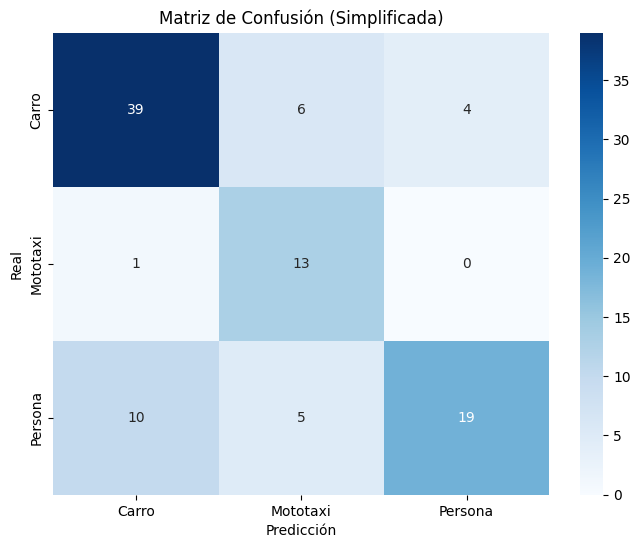

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, dataset, categories, threshold=0.5):
    all_preds = []
    all_gts = []
    
    model.eval()
    for i in range(len(dataset)):
        image, target = dataset[i]
        with torch.no_grad():
            pred = model([image.to(DEVICE)])[0]
        
        # Filtramos predicciones por confianza
        keep = pred["scores"] >= threshold
        pred_labels = pred["labels"][keep].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()
        
        # Nota simplificada: Esto asume que hay una coincidencia 1 a 1 por imagen.
        # Para detección real, se requiere cálculo de IoU, pero esto sirve de guía:
        if len(pred_labels) > 0 and len(gt_labels) > 0:
            all_preds.append(pred_labels[0]) # Tomamos la predicción principal
            all_gts.append(gt_labels[0])     # Tomamos el objeto real principal

    cm = confusion_matrix(all_gts, all_preds, labels=list(categories.keys()))
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=categories.values(), 
                yticklabels=categories.values())
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión (Simplificada)')
    plt.show()

# Ejecutar la matriz
plot_confusion_matrix(model, test_ds, categories, threshold=0.6)

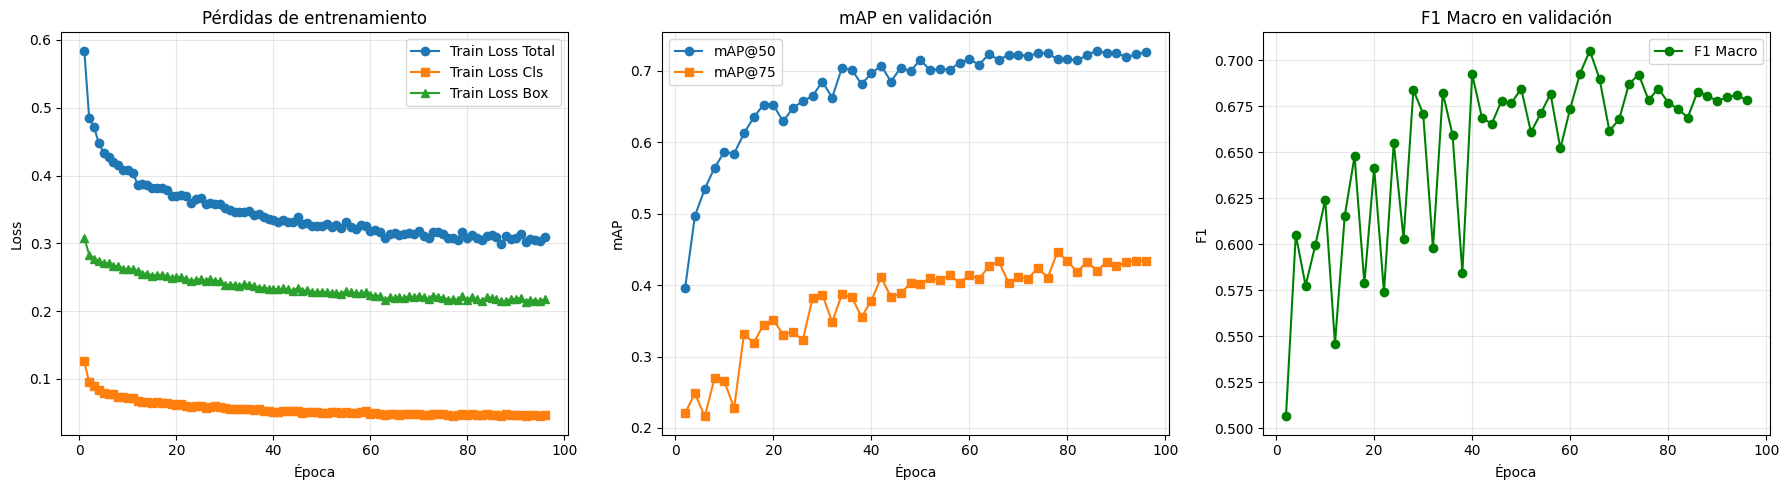

In [29]:
import pandas as pd

df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(df["epoch"], df["train_loss_total"], label="Train Loss Total", marker="o")
axes[0].plot(df["epoch"], df["train_loss_cls"], label="Train Loss Cls", marker="s")
axes[0].plot(df["epoch"], df["train_loss_box"], label="Train Loss Box", marker="^")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Pérdidas de entrenamiento")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mAP
val_epochs = df[df["val_map50"] > 0]["epoch"]
axes[1].plot(val_epochs, df[df["val_map50"] > 0]["val_map50"], label="mAP@50", marker="o")
axes[1].plot(val_epochs, df[df["val_map50"] > 0]["val_map75"], label="mAP@75", marker="s")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("mAP")
axes[1].set_title("mAP en validación")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1
axes[2].plot(val_epochs, df[df["val_map50"] > 0]["val_macro_f1"], label="F1 Macro", marker="o", color="green")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("F1")
axes[2].set_title("F1 Macro en validación")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 13. Evaluación final en Test

In [30]:
# Cargar mejor modelo
best_ckpt = torch.load(ckpt_dir / "best_model.pth", map_location=DEVICE)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"[INFO] Modelo de época {best_ckpt['epoch']} cargado (mAP@50 val: {best_ckpt['best_map50']:.4f})")


[INFO] Modelo de época 86 cargado (mAP@50 val: 0.7283)


In [31]:
test_metrics = evaluate(model, test_loader, "test", categories, score_threshold=CONFIG["score_threshold"])
print(f"\n[INFO] Mejor mAP@50 (val): {best_map50:.4f}")
print(f"[INFO] mAP@50 (test):      {test_metrics['map50']:.4f}")
print(f"[INFO] F1 macro (test):    {test_metrics['macro_f1']:.4f}")


Evaluando [TEST]: 100%|██████████| 51/51 [00:03<00:00, 15.40it/s]



───────────────────────────────────────────────────────
  [TEST] Métricas de Evaluación
───────────────────────────────────────────────────────
  mAP@50      : 0.6837
  mAP@75      : 0.3825
  mAP@50:95   : 0.5331
  F1 macro    : 0.6466

  F1 por clase (score_threshold=0.5):
    Carro                 P=0.793  R=0.770  F1=0.781
    Mototaxi              P=0.464  R=0.912  F1=0.615
    Persona               P=0.516  R=0.574  F1=0.543

  AP@[.50:.75] por clase (SIN score_threshold, ranking completo):
    Carro                 AP=0.6418
    Mototaxi              AP=0.6429
    Persona               AP=0.3147
───────────────────────────────────────────────────────


[INFO] Mejor mAP@50 (val): 0.7283
[INFO] mAP@50 (test):      0.6837
[INFO] F1 macro (test):    0.6466


In [32]:
results = {
    "config": CONFIG, "categories": categories,
    "best_epoch": best_ckpt["epoch"], "best_map50": best_map50,
    "test_metrics": test_metrics, "history": history,
}
with open(ckpt_dir / "training_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"[INFO] Resultados guardados en: {ckpt_dir / 'training_results.json'}")


[INFO] Resultados guardados en: checkpoints\training_results.json


## 14. Visualización de predicciones en test

In [33]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

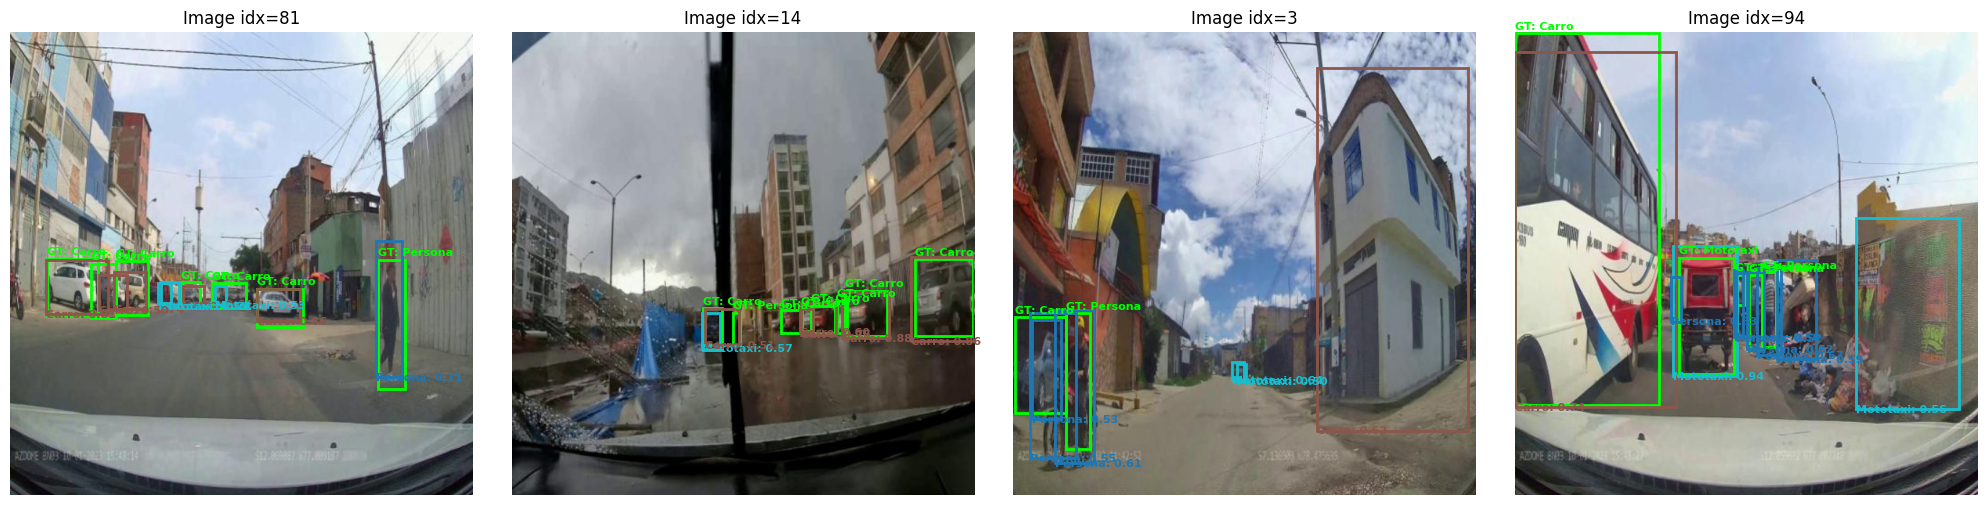

In [34]:
def visualize_predictions(model, dataset, categories, num_samples=4, score_threshold=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    if num_samples == 1:
        axes = [axes]

    class_colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

    for ax, idx in zip(axes, indices):
        image, target = dataset[idx]
        with torch.no_grad():
            pred = model([image.to(DEVICE)])[0]

        # Desnormalizar imagen para visualización
        img_np = image.cpu().numpy().transpose(1, 2, 0)
        img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_np = np.clip(img_np, 0, 1)

        ax.imshow(img_np)
        ax.set_title(f"Image idx={idx}")
        ax.axis("off")

        # GT boxes (verde)
        gt_boxes = target["boxes"].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()
        for box, label in zip(gt_boxes, gt_labels):
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                     linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            ax.text(box[0], box[1] - 5, f"GT: {categories.get(label, label)}",
                    color="lime", fontsize=8, fontweight="bold")

        # Pred boxes (rojo)
        keep = pred["scores"] >= score_threshold
        pred_boxes = pred["boxes"][keep].cpu().numpy()
        pred_labels = pred["labels"][keep].cpu().numpy()
        pred_scores = pred["scores"][keep].cpu().numpy()
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            color = class_colors[label % len(class_colors)]
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                     linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(box[0], box[3] + 5, f"{categories.get(label, label)}: {score:.2f}",
                    color=color, fontsize=8, fontweight="bold")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_ds, categories, num_samples=4)


## 15. Subir modelo a Hugging Face

In [35]:
!pip install huggingface_hub


Defaulting to user installation because normal site-packages is not writeable


In [36]:
import os
from huggingface_hub import login, HfApi

HF_REPO_ID = "pollitoconpapass/carritos-detectorV2"  # ej: "mi-usuario/carritos-detector-frcnn"
HF_TOKEN = os.environ.get("HF_TOKEN")            # lee de variable de entorno

if HF_TOKEN is None:
    HF_TOKEN = input("Pega tu token de Hugging Face (hf_...): ").strip()

login(token=HF_TOKEN)
print("[INFO] Sesion iniciada en Hugging Face.")


[INFO] Sesion iniciada en Hugging Face.


In [37]:
# Guardar checkpoint liviano para inference (sin optimizer/scheduler)
inference_ckpt = {
    "model_state_dict": model.state_dict(),
    "categories": categories,
    "num_classes": CONFIG["num_classes"],
    "config": {
        "num_classes": CONFIG["num_classes"],
        "image_size": 640,
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225],
    },
    "best_map50": best_map50,
    "best_epoch": best_ckpt["epoch"],
}

hf_upload_dir = Path("./hf_upload")
hf_upload_dir.mkdir(exist_ok=True)
model_path = hf_upload_dir / "model.pt"
torch.save(inference_ckpt, model_path)
print(f"[INFO] Checkpoint de inference guardado en: {model_path}")
print(f"[INFO] Tamano: {model_path.stat().st_size / 1e6:.1f} MB")


[INFO] Checkpoint de inference guardado en: hf_upload\model.pt
[INFO] Tamano: 165.7 MB


In [38]:
api = HfApi()

# Crear repo si no existe
api.create_repo(repo_id=HF_REPO_ID, exist_ok=True, repo_type="model")

# Subir el modelo
api.upload_file(
    path_or_fileobj=str(model_path),
    path_in_repo="model.pt",
    repo_id=HF_REPO_ID,
    repo_type="model",
    commit_message=f"Upload Faster R-CNN model (mAP@50={best_map50:.4f}, epoch={best_ckpt['epoch']})",
)
print(f"[INFO] Modelo subido a: https://huggingface.co/{HF_REPO_ID}")


Processing Files (1 / 1): 100%|██████████|  166MB /  166MB, 7.35MB/s  
New Data Upload: 100%|██████████|  160MB /  160MB, 7.20MB/s  


[INFO] Modelo subido a: https://huggingface.co/pollitoconpapass/carritos-detectorV2


In [39]:
# Subir model card (README.md del repo)
model_card = f"""
# Carritos Detector - Faster R-CNN (ResNet-50-FPN)

Modelo de deteccion de vehiculos entrenado con PyTorch Faster R-CNN + ResNet-50-FPN backbone.

## Clases

| ID | Clase | Descripcion |
|----|-------|-------------|
| 1 | Carro | Incluye carros, buses, camiones y combis |
| 2 | Mototaxi | Mototaxis |
| 3 | Persona | Personas |

## Metricas

- **mAP@50 (val):** {best_map50:.4f}
- **Epoca:** {best_ckpt['epoch']}
- **Clases:** {len(categories)} + background
- **Input:** 640x640 RGB

## Uso con torch.hub

```python
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Descargar checkpoint
ckpt = torch.hub.load_state_dict_from_url(
    "https://huggingface.co/{HF_REPO_ID}/resolve/main/model.pt",
    map_location="cpu",
)

# Reconstruir modelo
model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, ckpt["num_classes"])
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Clases: {{ckpt['categories']}}")
```

## Entrenado con

- PyTorch {torch.__version__}
- Faster R-CNN ResNet-50-FPN (pre-entrenado en COCO)
- Fine-tuning de layer3 + layer4 del backbone
- Focal Loss + class weights para desbalance de clases
- 30 epocas, batch_size=2, SGD con cosine annealing
"""

api.upload_file(
    path_or_fileobj=model_card.encode("utf-8"),
    path_in_repo="README.md",
    repo_id=HF_REPO_ID,
    repo_type="model",
    commit_message="Add model card",
)
print(f"[INFO] Model card subida.")
print(f"[INFO] Repo completo: https://huggingface.co/{HF_REPO_ID}")


Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card


[INFO] Model card subida.
[INFO] Repo completo: https://huggingface.co/pollitoconpapass/carritos-detectorV2


## 16. Probar modelo desde Hugging Face

Descarga el modelo desde HF y ejecuta inference en una imagen del test set.

In [40]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

hf_model_url = f"https://huggingface.co/{HF_REPO_ID}/resolve/main/model.pt"
ckpt_hf = torch.hub.load_state_dict_from_url(hf_model_url, map_location=DEVICE)

model_hf = fasterrcnn_resnet50_fpn(weights=None)
in_features = model_hf.roi_heads.box_predictor.cls_score.in_features
model_hf.roi_heads.box_predictor = FastRCNNPredictor(in_features, ckpt_hf["num_classes"])
model_hf.load_state_dict(ckpt_hf["model_state_dict"])
model_hf.to(DEVICE)
model_hf.eval()

categories_hf = ckpt_hf["categories"]
print(f"[INFO] Modelo cargado desde HF (epoca {ckpt_hf['best_epoch']}, mAP@50={ckpt_hf['best_map50']:.4f})")
print(f"[INFO] Clases: {categories_hf}")


[INFO] Modelo cargado desde HF (epoca 46, mAP@50=0.6904)
[INFO] Clases: {1: 'Carro', 2: 'Mototaxi', 3: 'Persona'}


In [41]:
def infer_image(model, image_path, categories, score_threshold=0.5):
    """Inference en una imagen individual con visualizacion."""
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"No se pudo cargar: {image_path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    transform = A.Compose([
        A.Resize(640, 640),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])
    tensor = transform(image=image_rgb)["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(tensor)[0]

    keep = pred["scores"] >= score_threshold
    boxes = pred["boxes"][keep].cpu().numpy()
    labels = pred["labels"][keep].cpu().numpy()
    scores = pred["scores"][keep].cpu().numpy()

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(image_rgb)
    ax.set_title(f"Predicciones (threshold={score_threshold})")
    ax.axis("off")

    class_colors = {1: "red", 2: "cyan", 3: "lime"}
    h_orig, w_orig = image_rgb.shape[:2]
    sx, sy = w_orig / 640, h_orig / 640

    for box, label, score in zip(boxes, labels, scores):
        color = class_colors.get(label, "white")
        x1, y1 = box[0] * sx, box[1] * sy
        w, h = (box[2] - box[0]) * sx, (box[3] - box[1]) * sy
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{categories.get(label, label)}: {score:.2f}",
                color=color, fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7))

    plt.tight_layout()
    plt.show()

    print(f"Detecciones: {len(boxes)}")
    for label, score in zip(labels, scores):
        print(f"  {categories.get(label, label):12s} conf={score:.3f}")


[INFO] Probando con: Carritos-Detector-1\test\frame_0005_png.rf.0635c3b6280d0a9e91b05562ebda91ba.jpg


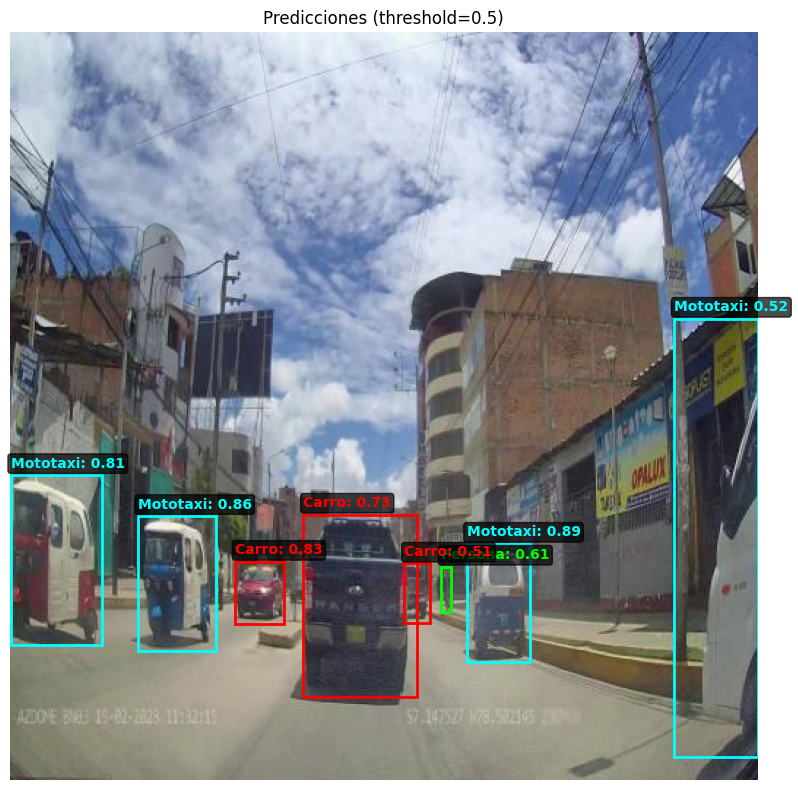

Detecciones: 8
  Mototaxi     conf=0.888
  Mototaxi     conf=0.859
  Carro        conf=0.827
  Mototaxi     conf=0.809
  Carro        conf=0.729
  Persona      conf=0.612
  Mototaxi     conf=0.518
  Carro        conf=0.513


In [42]:
# Probar con una imagen del test set
test_images = list((dataset_dir / "test").glob("*.jpg"))
if not test_images:
    test_images = list((dataset_dir / "test").glob("*.png"))

if test_images:
    example_image = test_images[0]
    print(f"[INFO] Probando con: {example_image}")
    infer_image(model_hf, example_image, categories_hf, score_threshold=0.5)
else:
    print("[WARN] No se encontraron imagenes en test/.")
    print("Usa: infer_image(model_hf, 'ruta/imagen.jpg', categories_hf)")
